In [143]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import immrax as irx

In [144]:
import os, sys
import pickle

sys.path.append("/home/user/output_feedback/nhholyap/examples/")
from functools import partial
from jax import jit, lax, vmap
import matplotlib.pyplot as plt
# from admire import AdmireNineDoFLinAct
from faulty_car.interval_functions import overlap_size_lax, overlap_size, overlap_sum_lax, overlap_size_lax_scaled
import time, copy
from typing import Optional, Dict, Any, Tuple, List
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Rectangle

### Contact Model: Sigmoid function

We need to define a scaling factor for contact force. A modified sigmoid function will do. This contact model will yield 0.9F at 1cm of penetration and 0.1F at 0cm of penetration (i.e. contact) 

In [145]:
# The parameters we calculated
k = 200 * jnp.log(9)  # Use the exact value for precision
c = -0.005
# Our final, modified sigmoid function
def modified_mirrored_sigmoid(x):
    return 1 / (1 + jnp.exp(k * (x - c)))

f(0) = 0.1000
f(-0.01) = 0.9000


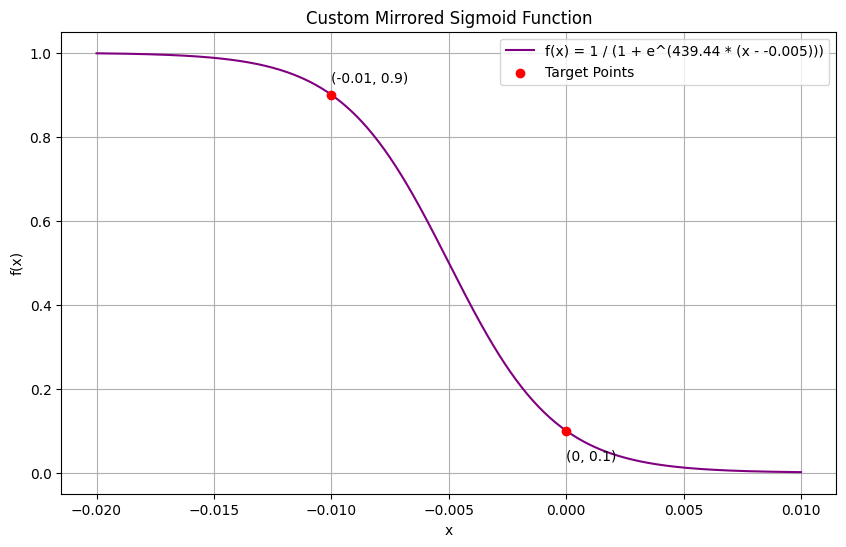

In [146]:
# --- Verification ---
# Check f(0)
val_at_0 = modified_mirrored_sigmoid(0)
print(f"f(0) = {val_at_0:.4f}")  # Should be 0.1000
# Check f(-0.01)
val_at_neg_0_01 = modified_mirrored_sigmoid(-0.01)
print(f"f(-0.01) = {val_at_neg_0_01:.4f}") # Should be 0.9000
# --- Visualization ---
# Define a suitable x-range around our points of interest
x = np.linspace(-0.02, 0.01, 500)
y = modified_mirrored_sigmoid(x)
# The specific points we wanted to fit
points_x = [-0.01, 0]
points_y = [0.9, 0.1]
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'f(x) = 1 / (1 + e^({k:.2f} * (x - {c})))', color='purple')
plt.scatter(points_x, points_y, color='red', zorder=5, label='Target Points')
plt.text(points_x[0], points_y[0] + 0.03, '(-0.01, 0.9)')
plt.text(points_x[1], points_y[1] - 0.07, '(0, 0.1)')
# Plot details
plt.title('Custom Mirrored Sigmoid Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

### Forward Kinematics

Also we need a closed form solution to arm's forward kinematics.

In [147]:
def fk_ee(q, L):
    return jnp.array([
        jnp.cos(q[0]) + jnp.cos(q[0] + q[1]),
        jnp.sin(q[0]) + jnp.sin(q[0] + q[1]),
    ]) * L

def fk_mid_joint1(q, L):
    return jnp.array([
        jnp.cos(q[0]),
        jnp.sin(q[0]),
    ]) * L / 2.


### Signed Distance Function

$$\phi(q) = y_{obj} - y_{arm}(q)$$

In [148]:
def naive_sdf(arm_pos, obj_pos):
    return obj_pos[1] - arm_pos[1]

In [149]:
L = .5
y_obj_1 = 0.
y_obj_2 = L * jnp.cos(jnp.pi / 6.)
obj1_pos = jnp.array([0., y_obj_1,])
obj2_pos = jnp.array([0., y_obj_2,])
q = jnp.array([0., jnp.pi / 3. * 2.])
print(naive_sdf(fk_ee(q, L), obj2_pos))
print(naive_sdf(fk_mid_joint1(q, L), obj1_pos))
p_ivl = irx.icentpert(jnp.array([obj2_pos[0], obj2_pos[1], 10.]), jnp.ones(1) * .1)

0.0
0.0


In [150]:
print(fk_ee(q, L))
print(y_obj_2)


[0.24999997 0.4330127 ]
0.4330127


In [151]:
F = 100
class NaiveTwoLinkArmEEObs(irx.System):
    def __init__(self, L) -> None:
        super().__init__()
        self.L = L
        self.evolution = 'continuous'
        self.xlen = 4
        self.ulen = 2

    def f(self, t:float, x: jax.Array, u: jax.Array, p: jax.Array) -> jax.Array:
        """
        Implement manipulator equation here.
        Mqdd + Cqd = u + tau_g + J^TF
        """
        minv = jnp.eye(2)
        C = jnp.eye(2)
        qd = x[2:]
        tg = jnp.zeros(2)
        ee_pos = fk_ee(q, self.L)
        yee = ee_pos[1]
        joint1_mid_pos = fk_mid_joint1(q, self.L)
        y1 = joint1_mid_pos[1] * 2.
        force = p[-1]
        position = p[:1]
        tau_1 = force * yee
        tau_2 = force * (yee - y1)
        t_ext = jnp.array([tau_1, tau_2]) * modified_mirrored_sigmoid(naive_sdf(ee_pos, position))
        qdd = minv @ (-C @ qd + tg + u + t_ext)
        x_deriv = jnp.concatenate((qd, qdd))
        print(x_deriv.shape)
        return x_deriv
    
class NaiveTwoLinkArmMidlinkObs(irx.System):
    def __init__(self, L) -> None:
        super().__init__()
        self.L = L
        self.evolution = 'continuous'
        self.xlen = 4
        self.ulen = 2

    def f(self, t:float, x: jax.Array, u: jax.Array, p: jax.Array) -> jax.Array:
        """
        Implement manipulator equation here.
        Mqdd + Cqd = u + tau_g + J^TF
        """
        minv = jnp.eye(2)
        C = jnp.eye(2)
        qd = x[2:]
        tg = jnp.zeros(2)
        ee_pos = fk_ee(q, self.L)
        yee = ee_pos[1]
        joint1_mid_pos = fk_mid_joint1(q, self.L)
        y1 = joint1_mid_pos[1] * 2.
        y_midlink = joint1_mid_pos[1]
        force = p[-1]
        position = p[:1]
        tau_1 = force * y_midlink
        tau_2 = force * (y_midlink - y1)
        t_ext = jnp.array([tau_1, tau_2]) * modified_mirrored_sigmoid(naive_sdf(joint1_mid_pos, position))
        qdd = minv @ (-C @ qd + tg + u + t_ext)
        x_deriv = jnp.concatenate((qd, qdd))
        print(x_deriv.shape)
        return x_deriv
    

## Perform model discrimination

In [152]:
ee_contact_embsys = irx.natemb(NaiveTwoLinkArmEEObs(L))
midjoint_contact_embsys = irx.natemb(NaiveTwoLinkArmMidlinkObs(L))

def propagate_interval_euler_ee(x_ivl, u_ol, p_ivl, dt=0.01):
    return irx.ut2i(ee_contact_embsys.f(
        0, 
        irx.i2ut(x_ivl),
        u_ol,
        p_ivl,
    )) * dt + x_ivl


def propagate_interval_euler_midjoint(x_ivl, u_ol, p_ivl, dt=0.01):
    return irx.ut2i(midjoint_contact_embsys.f(
        0, 
        irx.i2ut(x_ivl),
        u_ol,
        p_ivl,
    )) * dt + x_ivl


def loss_ff_contact(u_ol, x_interval, p1, p2, dt, num_steps=10):
    """
    Loss function for the open-loop control input.
    This function is designed to be JIT-compiled.
    """
    # Propagate the initial state through the system dynamics
    def ee_step_fn(t, x_ivl):
        return propagate_interval_euler_ee(x_ivl, u_ol, p1, dt=dt)
    def mj_fault_step_fn(t, x_ivl):
        return propagate_interval_euler_midjoint(x_ivl, u_ol, p2, dt=dt)
    x_ivl_ee = jax.lax.fori_loop(0, num_steps, ee_step_fn, x_interval)
    x_ivl_mj = jax.lax.fori_loop(0, num_steps, mj_fault_step_fn, x_interval)
    # Calculate the loss as the squared difference between the propagated state and the observer offset
    loss = overlap_size_lax(
        x_ivl_ee, x_ivl_mj
    )
    
    return loss

In [153]:
loss_grad = jax.grad(loss_ff_contact, argnums=0)

def calculate_optimal_open_loop_u(x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    """
    Calculates the optimal open-loop control input `u` using a multi-start gradient descent.
    This entire function is designed to be JIT-compiled.
    """
    # This inner function performs one run of gradient descent from a random starting point.
    # def find_optimal_u():
    learning_rate = 1e2
    num_gd_steps = 10

    u_initial = jnp.ones(2) * 1e-2

    # # Define the body of the gradient descent loop
    def gradient_step(i, u_current):
        grad = loss_grad(u_current, x_interval, p_nominal, p_actuator_fault, dt, num_steps=num_steps)
        print(f"grad value: {grad}")
        return u_current - learning_rate * grad
    

    u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)

    return u_opt

In [154]:
dt = 0.1
num_steps=10
jit_calculate_optimal_open_loop_u = jit(partial(
    calculate_optimal_open_loop_u,
    p_nominal=p_ivl,
    p_actuator_fault=p_ivl,
    dt=dt,
    num_steps=num_steps
))

In [155]:
x0_interval = irx.icentpert(jnp.array([0., jnp.pi / 3 * 2., 0., 0.,]), jnp.zeros(4))

In [156]:
print(p_ivl)
calculate_optimal_open_loop_u(
    x_interval=x0_interval,
    p_nominal=p_ivl,
    p_actuator_fault=p_ivl,
    dt=dt,
    num_steps=num_steps
)

[[(-0.1       ,  0.1       )]
 [( 0.3330127 ,  0.53301269)]
 [( 9.89999962, 10.10000038)]]
(4,)
(4,)
grad value: Traced<ShapedArray(float32[2])>with<DynamicJaxprTrace>


Array([0.01, 0.01], dtype=float32)

In [157]:
jax.block_until_ready(jit_calculate_optimal_open_loop_u(x0_interval))

grad value: Traced<ShapedArray(float32[2])>with<DynamicJaxprTrace>


Array([0.01, 0.01], dtype=float32)

In [158]:
u = jit_calculate_optimal_open_loop_u(
    x0_interval
)

In [159]:
print(u)

[0.01 0.01]


In [160]:
loss_ff_contact(
    u_ol=u,
    x_interval=x0_interval,
    p1=p_ivl,
    p2=p_ivl,
    dt=dt,
    num_steps=num_steps
)

Array(0., dtype=float32, weak_type=True)